# Projet Walmart : Prédiction des ventes hebdomadaires

## Contexte
Walmart souhaite estimer ses ventes hebdomadaires à partir d'indicateurs économiques (température, prix du carburant, CPI, chômage) et contextuels (magasin, période de vacances). Ce projet vise à fournir un modèle prédictif fiable pour mieux piloter les campagnes marketing.

## Objectifs
1. Explorer et préparer les données (EDA et préprocessing).
2. Entraîner un modèle de régression linéaire (baseline).
3. Tester une régularisation Ridge / Lasso pour lutter contre l'overfitting.
4. Interpréter les coefficients pour identifier les facteurs clés des ventes.

## Points de vigilance méthodologique
Ce notebook applique plusieurs principes stricts de rigueur :
- **Aucune fuite de données** : toutes les transformations apprenantes (imputation, clipping, standardisation, encodage) sont ajustées sur le train uniquement.
- **Preprocessing dans la validation croisée** : le pipeline complet est évalué par `cross_val_score` et `GridSearchCV`, évitant toute contamination entre folds.
- **Comparaison train/test systématique** : pour détecter l'overfitting, on affiche toujours les deux.
- **Prudence sur le vocabulaire statistique** : on évite le mot « significatif » qui suppose un test d'hypothèse non réalisé ici.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Chargement du dataset
dataset = pd.read_csv("Walmart_Store_sales.csv")
print(f"Dataset chargé : {dataset.shape[0]} lignes, {dataset.shape[1]} colonnes")
dataset.head()

Dataset chargé : 150 lignes, 8 colonnes


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


## 1. Analyse exploratoire (EDA)

### 1.1 Structure et valeurs manquantes

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB


In [4]:
dataset.describe(include='all')

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


In [5]:
missing_pct = 100 * dataset.isnull().sum() / len(dataset)
missing_pct.sort_values(ascending=False)

Date            12.000000
Temperature     12.000000
Unemployment    10.000000
Weekly_Sales     9.333333
Fuel_Price       9.333333
Holiday_Flag     8.000000
CPI              8.000000
Store            0.000000
dtype: float64

### 1.2 Distribution des variables (analyse univariée)

Ces histogrammes montrent la **répartition de chaque variable** : asymétrie, pics, étendue.
**Attention** : ils n'apportent aucune information temporelle. Pour observer l'évolution dans le temps, voir la section 1.4.

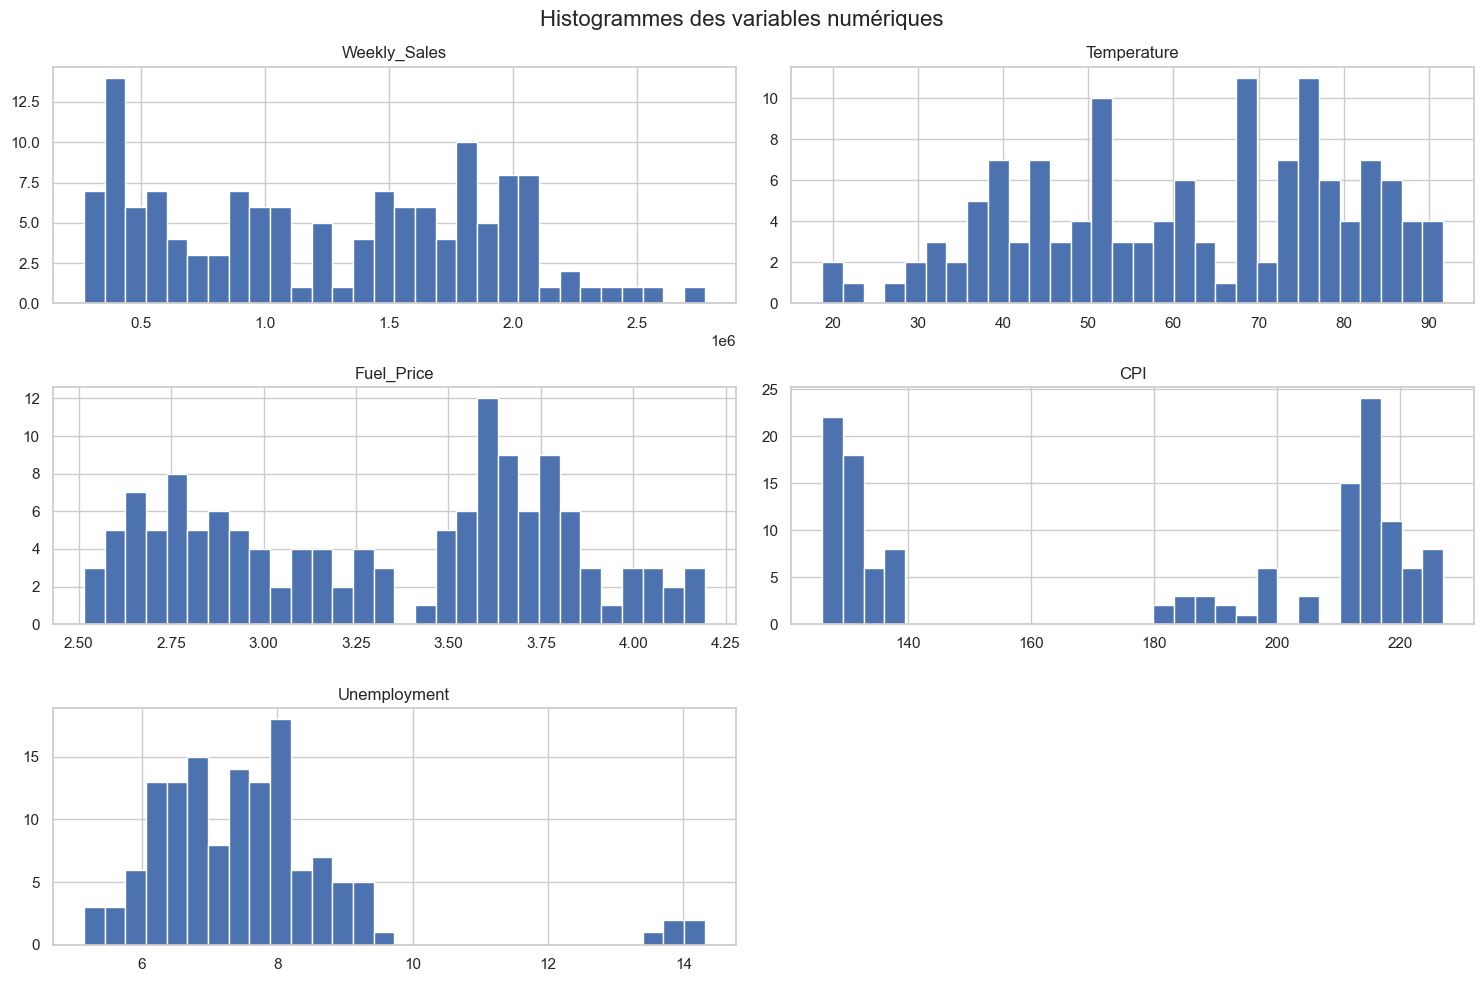

In [6]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
dataset[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogrammes des variables numériques", size=16)
plt.tight_layout()
plt.show()

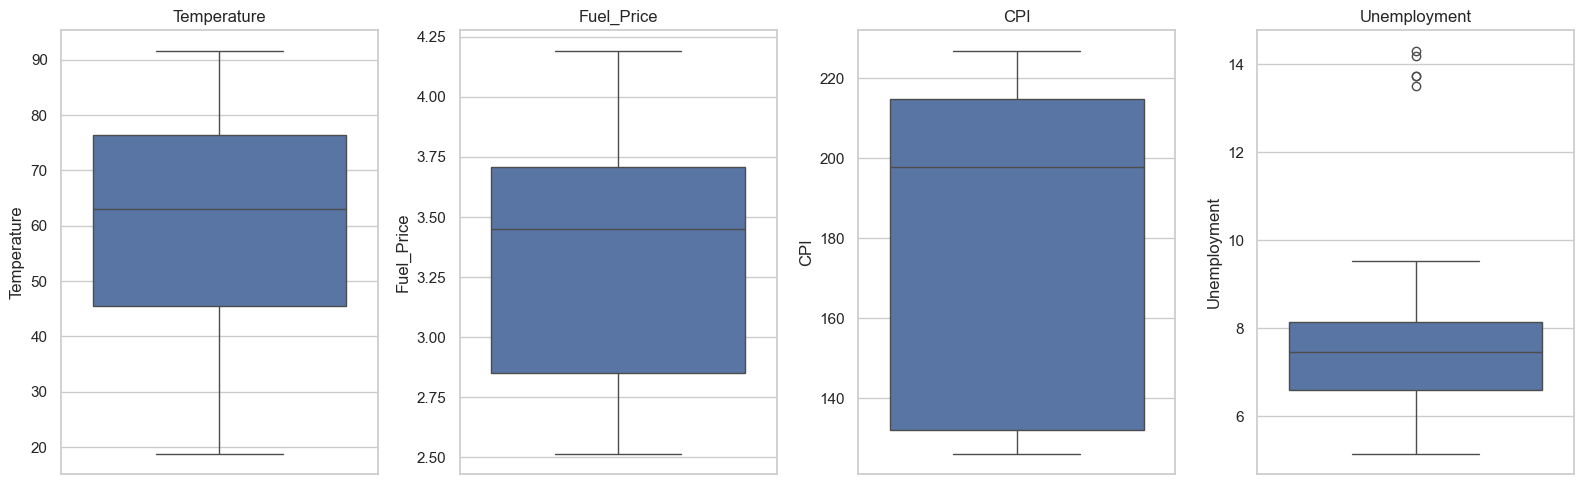

In [7]:
# Boxplots pour détecter visuellement les valeurs aberrantes
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']):
    sns.boxplot(y=dataset[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 1.3 Analyse multivariée : corrélations

La matrice de corrélation ci-dessous mesure les liens linéaires entre variables.
**Attention** : La corrélation entre CPI et Unemployment est modérée (≈ 0,35), ce qui ne constitue pas à elle seule un signal fort de multicolinéarité.

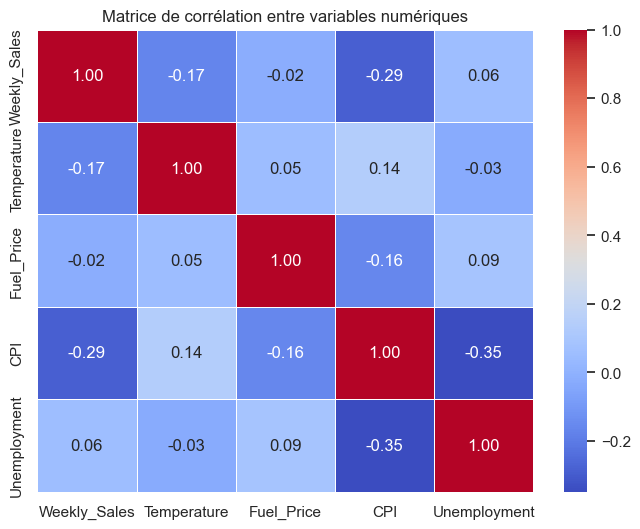

In [8]:
corr = dataset[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation entre variables numériques")
plt.show()

### 1.4 Évolution temporelle des ventes

Ce graphique trace `Weekly_Sales` en fonction de la `Date` pour observer la tendance, la saisonnalité et les éventuels pics.

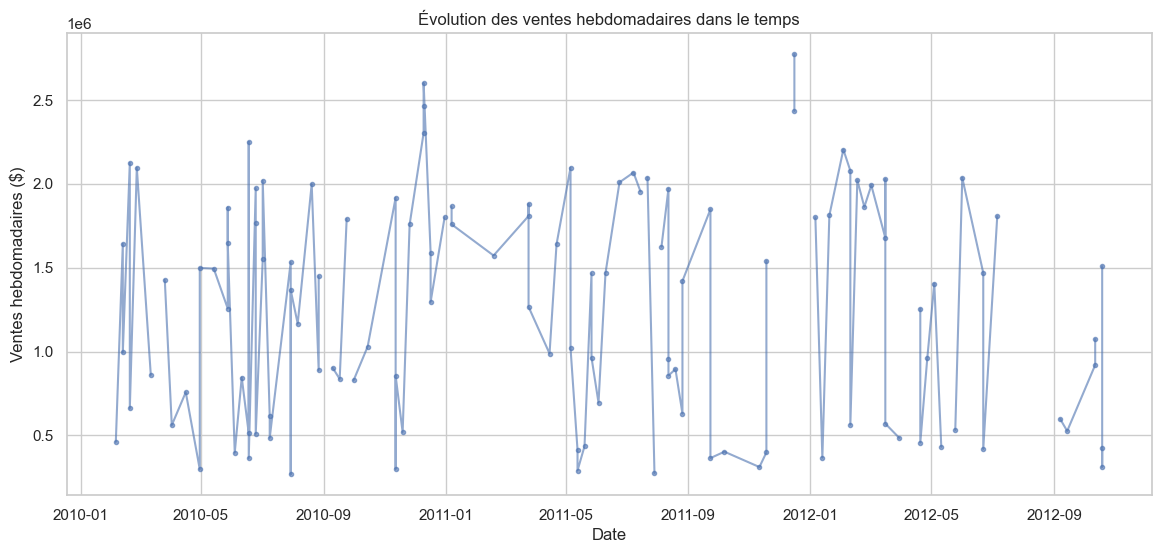

In [9]:
dataset_plot = dataset.copy()
dataset_plot['Date'] = pd.to_datetime(dataset_plot['Date'], errors='coerce')
dataset_plot = dataset_plot.dropna(subset=['Date']).sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(dataset_plot['Date'], dataset_plot['Weekly_Sales'], marker='.', linestyle='-', alpha=0.6)
plt.title("Évolution des ventes hebdomadaires dans le temps")
plt.xlabel("Date")
plt.ylabel("Ventes hebdomadaires ($)")
plt.grid(True)
plt.show()

**Observations :**
- La distribution des ventes est étalée avec quelques semaines exceptionnellement hautes (probablement des périodes de fêtes).
- Le prix du carburant et le CPI présentent quelques valeurs extrêmes.
- Corrélation CPI / Unemployment ≈ 0.35 : modérée, non problématique (VIF ≈ 1.14).
- La température est faiblement corrélée aux ventes.

**Attention** : plusieurs magasins sont présents à la même date, ce qui rend 
le graphe bruité. Pour observer une tendance, il faudrait agréger par date 
(moyenne des magasins) ou tracer chaque magasin séparément.

## 2. Préprocessing des données

### 2.0 Principes méthodologiques

Pour éviter toute fuite de données (*data leakage*) :
1. On fait le **split train/test avant tout traitement apprenant** (imputation, clipping, standardisation).
2. Chaque transformation apprend ses paramètres (moyennes, bornes, échelles) sur le **train uniquement**, puis les applique au test.
3. Pour la validation croisée, on utilisera un **Pipeline complet** pour que le preprocessing soit lui-même cross-validé.

### 2.1 Suppression des lignes sans cible
Imputer la cible introduirait un biais majeur dans l'apprentissage. On supprime donc ces lignes.

In [10]:
print(f"Lignes avant suppression : {len(dataset)}")
dataset = dataset.dropna(subset=['Weekly_Sales'])
print(f"Lignes après suppression : {len(dataset)}")

Lignes avant suppression : 150
Lignes après suppression : 136


### 2.2 Ingénierie des features temporelles

La colonne `Date` est convertie en plusieurs composantes. On distingue deux catégories :

**Features brutes retenues** :
- `Year` : capture la tendance long terme (année après année).
- `Day` : capture une tendance linéaire au fil du mois ( si elle existe).

**Features cycliques (sin/cos)** :
- Le mois (1→12) et le jour de la semaine (0→6) sont **cycliques** : Janvier et Décembre sont adjacents, alors qu'encodés en entiers ils sont éloignés (distance 11).
- Projeter ces variables sur un cercle via `sin` et `cos` permet au modèle linéaire de capter correctement la saisonnalité sans rupture artificielle.
- On **retire les versions brutes** `Month` et `DayOfWeek` : elles sont redondantes avec les composantes cycliques et n'apportent rien.

**Formules** :
- `Month_sin = sin(2π · Month / 12)` ; `Month_cos = cos(2π · Month / 12)`
- `Day_sin = sin(2π · DayOfWeek / 7)` ; `Day_cos = cos(2π · DayOfWeek / 7)`

In [11]:
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce')

# Composantes brutes utiles
dataset['Year'] = dataset['Date'].dt.year
dataset['Day']  = dataset['Date'].dt.day

# Composantes intermédiaires (pour calculer les cycliques)
month = dataset['Date'].dt.month
dayofweek = dataset['Date'].dt.dayofweek

# Features cycliques
dataset['Month_sin'] = np.sin(2 * np.pi * month / 12)
dataset['Month_cos'] = np.cos(2 * np.pi * month / 12)
dataset['Day_sin']   = np.sin(2 * np.pi * dayofweek / 7)
dataset['Day_cos']   = np.cos(2 * np.pi * dayofweek / 7)

# On supprime la colonne Date originale
dataset = dataset.drop(columns=['Date'])
dataset.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Day,Month_sin,Month_cos,Day_sin,Day_cos
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,18.0,0.866025,5.000000e-01,-0.433884,-0.900969
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,25.0,1.000000,6.123234e-17,-0.433884,-0.900969
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN,NaN,NaN
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,28.0,0.500000,-8.660254e-01,-0.433884,-0.900969
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,28.0,0.500000,-8.660254e-01,-0.433884,-0.900969


### 2.3 Séparation cible / features

La cible est `Weekly_Sales`. Toutes les autres colonnes sont candidates comme features explicatives.

In [12]:
X = dataset.drop(columns=['Weekly_Sales'])
Y = dataset['Weekly_Sales']
print("Dimensions de X :", X.shape)
print("Dimensions de Y :", Y.shape)

Dimensions de X : (136, 12)
Dimensions de Y : (136,)


### 2.4 Division train / test

**Choix : split aléatoire  (80 / 20).**

Le projet est présenté comme une **modélisation descriptive** (estimer la relation entre variables économiques et ventes), et non comme une prévision stricte sur des données futures. Un split temporel serait plus rigoureux si l'objectif était de prévoir 2013 à partir de 2010-2012, mais il réduirait drastiquement l'ensemble de test (28 lignes) et introduirait une instabilité d'évaluation.

**Piste d'amélioration identifiée** : tester un split temporel et comparer les performances — c'est mentionné dans la section Limites.

**Important** : ce split est fait **avant tout traitement apprenant** (imputation, clipping, standardisation) pour éviter toute fuite.

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]} lignes, Test : {X_test.shape[0]} lignes")

Train : 108 lignes, Test : 28 lignes


### 2.5 Gestion des valeurs aberrantes (clipping)

**Principe du clipping** : au lieu de supprimer les lignes aberrantes (ce qui réduirait la taille du dataset), on ramène les valeurs extrêmes aux bornes `[μ - 3σ, μ + 3σ]`.

**Règle anti-fuite** : les bornes sont calculées **sur le train uniquement**, puis appliquées au test. Cela évite que les valeurs du test influencent le prétraitement du train.

Dans la suite, cette étape sera intégrée à l'intérieur du pipeline pour être correctement cross-validée. On la définit ici sous forme de transformer Scikit-Learn personnalisé.

In [14]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Clippe les valeurs numériques à ±n_std écarts-types.
    Les bornes sont apprises sur le train (fit) et appliquées à l'identique
    sur le test (transform) pour éviter toute fuite de données.
    """
    def __init__(self, n_std=3):
        self.n_std = n_std

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_ = (X_df.mean() - self.n_std * X_df.std()).values
        self.upper_ = (X_df.mean() + self.n_std * X_df.std()).values
        return self

    def transform(self, X):
        return np.clip(np.asarray(X), self.lower_, self.upper_)

### 2.6 Construction du pipeline complet

Le pipeline enchaîne, dans l'ordre :

1. **Clipping** des variables économiques (Temperature, Fuel_Price, CPI, Unemployment) — bornes ±3σ.
2. **Imputation** des valeurs manquantes (moyenne pour les numériques, mode pour les catégorielles).
3. **Encodage** des variables catégorielles (`Store`, `Holiday_Flag`) par One-Hot Encoding (`drop='first'` pour éviter la colinéarité parfaite).
4. **Standardisation globale** (StandardScaler) appliquée **après** l'encodage : indispensable pour que Ridge et Lasso pénalisent équitablement toutes les features, y compris les variables One-Hot.
5. **Modèle** (laissé interchangeable : Linear, Ridge, Lasso).

Ce pipeline est utilisé intégralement (fit + predict) et sert de base à `cross_val_score` et `GridSearchCV`.

In [15]:
# Définition des groupes de colonnes
clipped_features     = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
other_numeric_features = ['Year', 'Day', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']
categorical_features = ['Store', 'Holiday_Flag']

# Bloc "clipping + imputation" pour les features économiques
clipped_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('clipper', OutlierClipper(n_std=3)),
])

# Bloc "imputation simple" pour les autres features numériques
other_numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
])

# Bloc catégoriel
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

# Préprocesseur : combine les 3 blocs
preprocessor = ColumnTransformer(transformers=[
    ('clip', clipped_pipeline, clipped_features),
    ('num',  other_numeric_pipeline, other_numeric_features),
    ('cat',  categorical_pipeline, categorical_features),
])

print("Préprocesseur construit.")

Préprocesseur construit.


In [16]:
# Fonction utilitaire pour évaluer les modèles
def print_metrics(y_true, y_pred, set_name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{set_name:20s} : R² = {r2:.4f}, RMSE = {rmse:>10,.0f} $, MAE = {mae:>10,.0f} $")

def build_pipeline(model):
    """Retourne un pipeline complet (preprocessing + scaling final + modèle)."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', model),
    ])

**Note technique** : on utilise `StandardScaler(with_mean=False)` car 
les données en sortie du ColumnTransformer contiennent des colonnes 
One-Hot creuses. Centrer ces colonnes (soustraction de la moyenne) 
détruirait leur structure creuse et ferait exploser la mémoire. On 
standardise donc uniquement par l'écart-type.

## 3. Modélisation – Régression linéaire (baseline)

Modèle : `LinearRegression` encapsulé dans le pipeline complet.

In [17]:
lin_pipe = build_pipeline(LinearRegression())
lin_pipe.fit(X_train, Y_train)

Y_train_pred_lr = lin_pipe.predict(X_train)
Y_test_pred_lr  = lin_pipe.predict(X_test)

print("Performance du modèle de régression linéaire :")
print_metrics(Y_train, Y_train_pred_lr, "Train")
print_metrics(Y_test,  Y_test_pred_lr,  "Test")

Performance du modèle de régression linéaire :
Train                : R² = 0.9702, RMSE =    110,435 $, MAE =     77,483 $
Test                 : R² = 0.9239, RMSE =    183,536 $, MAE =    132,032 $


**Interprétation** : l'écart entre R² train et R² test indique le niveau d'overfitting. On le comparera aux modèles régularisés dans la section suivante.

### 3.1 Interprétation des coefficients (baseline)

Les coefficients sont extraits après le pipeline complet. Comme toutes les features (numériques et catégorielles encodées) sont standardisées par le `StandardScaler` final du pipeline, **leurs coefficients sont comparables en magnitude** :

- Les features sont mises à l'échelle par leur écart-type. Le centrage est désactivé (with_mean=False) afin de préserver la représentation sparse issue du One-Hot Encoding.

Nous trions donc les coefficients par **valeur absolue** pour identifier les features les plus influentes.



In [18]:
# Récupération des noms de features après transformation
cat_feature_names = (lin_pipe.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(categorical_features))
all_feature_names = clipped_features + other_numeric_features + list(cat_feature_names)

# Extraction des coefficients
coefficients = lin_pipe.named_steps['model'].coef_
coef_df = pd.DataFrame({
    'feature':     all_feature_names,
    'coefficient': coefficients
})

# Les features sont déjà standardisées par le pipeline (StandardScaler en fin de pipeline).
# Les coefficients sont donc directement comparables en magnitude : pas besoin de
# normalisation supplémentaire.

# Tri par valeur absolue pour identifier les features les plus influentes
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
top_coef = coef_df.sort_values('abs_coefficient', ascending=False).head(10)

top_coef[['feature', 'coefficient']]

,feature,coefficient
11,Store_3.0,-353956.146451
13,Store_5.0,-295663.120671
24,Store_16.0,-195658.103635
17,Store_9.0,-181370.371581
22,Store_14.0,177085.420198
16,Store_8.0,-171115.783921
15,Store_7.0,-159760.159885
21,Store_13.0,142054.630978
23,Store_15.0,-135613.275945
12,Store_4.0,128110.261242


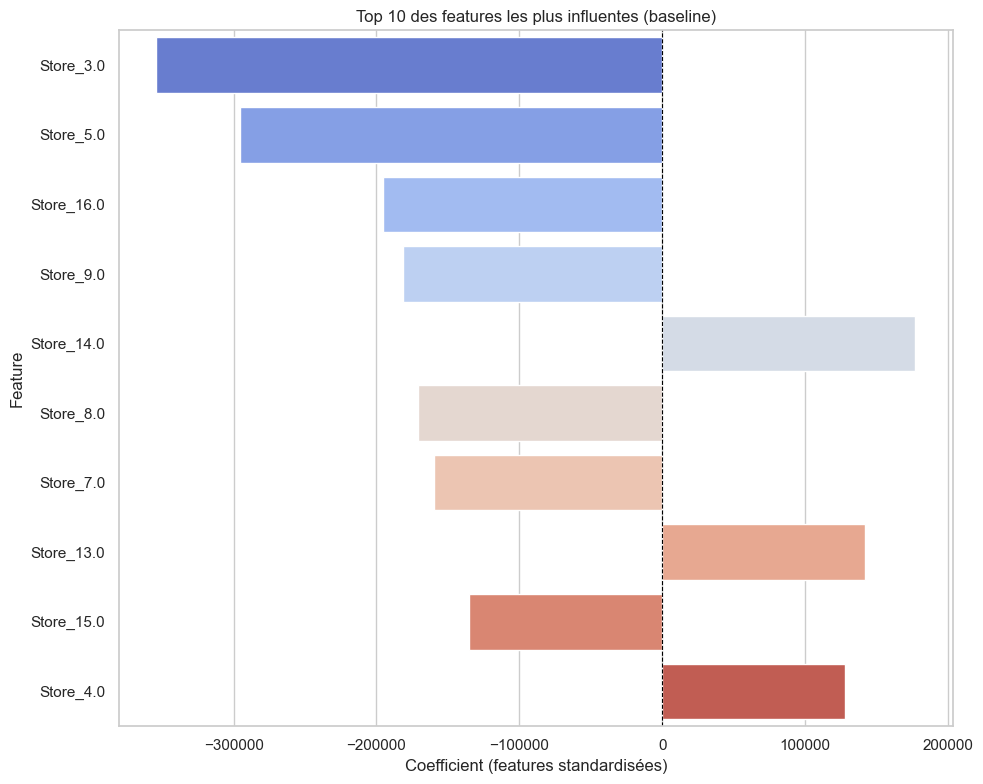

In [19]:
plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef, x='coefficient', y='feature', palette='coolwarm')
plt.title("Top 10 des features les plus influentes (baseline)")
plt.xlabel("Coefficient (features standardisées)")
plt.ylabel("Feature")
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

**Interprétation** :

- Le graphique ci-dessus montre les 10 features dont l'influence est la plus marquée **sur les données standardisées**.
- On observe que **toutes les features du top 10 sont des variables `Store`** : Les coefficients associés aux magasins dominent le classement, ce qui indique que les différences structurelles de niveau de ventes entre magasins expliquent une part importante de la variabilité observée.. Un même niveau de température, de CPI ou de chômage n'a pas le même effet selon le point de vente.
- Les variables macro-économiques (CPI, Unemployment) et cycliques (Month_sin, Month_cos) ont des coefficients beaucoup plus faibles en valeur absolue : elles jouent un rôle **secondaire**, mais non nul.
- **Note sur l'interprétation des signes** : un coefficient positif signifie que la feature est associée à une hausse des ventes par rapport à la catégorie de référence (Store_1, la première modalité de Store utilisée comme catégorie de référence par le One-Hot Encoding.). Un coefficient négatif signifie l'inverse.
- **Attention méthodologique** : ces coefficients décrivent une **association statistique** dans le dataset, pas une **relation causale**. Interpréter le signe d'un coefficient comme un effet causal serait une erreur.

## 4. Régularisation – Ridge et Lasso

**Objectif** : lutter contre l'overfitting en pénalisant les coefficients trop grands.

**Méthodologie rigoureuse** : on utilise `GridSearchCV` sur le **pipeline complet** (preprocessing inclus). Cela évite les fuites entre folds puisque chaque fold de validation reçoit son propre preprocessing ajusté sur son train interne.

**Grille d'alpha** : on balaie `np.logspace(-3, 6, 200)`, soit 200 valeurs de 0.001 à 1 000 000. Une plage étendue est nécessaire ici car la cible est sur une échelle en millions de dollars : l'alpha optimal du Lasso peut s'avérer élevé. Si l'optimum tombe sur une borne, il faudra étendre encore la plage — nous vérifions cela explicitement ci-dessous.

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
alpha_grid = {'model__alpha': np.logspace(-3, 6, 200)}

# Ridge
ridge_pipe = build_pipeline(Ridge())
ridge_gs = GridSearchCV(ridge_pipe, alpha_grid, cv=cv, scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train, Y_train)
print(f"Ridge — meilleur alpha : {ridge_gs.best_params_['model__alpha']:.4f}")
print(f"Ridge — meilleur R² CV : {ridge_gs.best_score_:.4f}")

# Lasso
lasso_pipe = build_pipeline(Lasso(max_iter=50000))
lasso_gs = GridSearchCV(lasso_pipe, alpha_grid, cv=cv, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train, Y_train)
print(f"Lasso — meilleur alpha : {lasso_gs.best_params_['model__alpha']:.4f}")
print(f"Lasso — meilleur R² CV : {lasso_gs.best_score_:.4f}")

Ridge — meilleur alpha : 0.7843
Ridge — meilleur R² CV : 0.9159
Lasso — meilleur alpha : 1414.9913
Lasso — meilleur R² CV : 0.9164


**Vérification des bornes** : si l'alpha optimal tombe exactement sur la borne inférieure ou supérieure de la grille, cela signifie que la vraie valeur optimale se situe en dehors de la plage testée. Il faut alors étendre la grille. Cette vérification est essentielle pour s'assurer que la recherche d'hyperparamètres est fiable.

In [21]:
# 1) Extraction des alphas optimaux depuis GridSearchCV
best_alpha_ridge = ridge_gs.best_params_['model__alpha']
best_alpha_lasso = lasso_gs.best_params_['model__alpha']

# 2) Récupération des bornes réelles de la grille utilisée
alpha_values = alpha_grid['model__alpha']
lower, upper = alpha_values[0], alpha_values[-1]
print(f"Bornes de la grille réelle : [{lower:.6f}, {upper:.6f}]\n")

# 3) Vérification explicite que les alphas optimaux sont bien à l'intérieur
for name, alpha in [("Ridge", best_alpha_ridge), ("Lasso", best_alpha_lasso)]:
    if alpha == lower:
        print(f"⚠️ {name} : alpha à la borne INFÉRIEURE → étendre la grille vers le bas")
    elif alpha == upper:
        print(f"⚠️ {name} : alpha à la borne SUPÉRIEURE → étendre la grille vers le haut")
    else:
        print(f"✅ {name} : alpha optimal à l'intérieur de la grille ({alpha:.4f})")

Bornes de la grille réelle : [0.001000, 1000000.000000]

✅ Ridge : alpha optimal à l'intérieur de la grille (0.7843)
✅ Lasso : alpha optimal à l'intérieur de la grille (1414.9913)


### 4.1 Évaluation complète : train et test pour les trois modèles

Pour juger l'effet réel de la régularisation, il faut **regarder simultanément les scores train et test**. Un modèle qui obtient un bon R² test mais un R² train beaucoup plus élevé est en overfitting ; un modèle dont l'écart train/test est faible généralise mieux.

In [22]:
# Meilleurs modèles retrouvés par GridSearchCV
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_

Y_train_pred_ridge = best_ridge.predict(X_train)
Y_test_pred_ridge  = best_ridge.predict(X_test)
Y_train_pred_lasso = best_lasso.predict(X_train)
Y_test_pred_lasso  = best_lasso.predict(X_test)

print("Comparaison train / test sur les 3 modèles :\n")
print_metrics(Y_train, Y_train_pred_lr,    "Linear (train)")
print_metrics(Y_test,  Y_test_pred_lr,     "Linear (test)")
print()
print_metrics(Y_train, Y_train_pred_ridge, "Ridge  (train)")
print_metrics(Y_test,  Y_test_pred_ridge,  "Ridge  (test)")
print()
print_metrics(Y_train, Y_train_pred_lasso, "Lasso  (train)")
print_metrics(Y_test,  Y_test_pred_lasso,  "Lasso  (test)")

Comparaison train / test sur les 3 modèles :

Linear (train)       : R² = 0.9702, RMSE =    110,435 $, MAE =     77,483 $
Linear (test)        : R² = 0.9239, RMSE =    183,536 $, MAE =    132,032 $

Ridge  (train)       : R² = 0.9699, RMSE =    110,902 $, MAE =     77,806 $
Ridge  (test)        : R² = 0.9227, RMSE =    184,977 $, MAE =    133,530 $

Lasso  (train)       : R² = 0.9698, RMSE =    111,161 $, MAE =     78,033 $
Lasso  (test)        : R² = 0.9228, RMSE =    184,853 $, MAE =    132,353 $


### 4.2 Tableau récapitulatif

Synthèse sous forme de tableau pour comparaison directe.

In [23]:
results = pd.DataFrame({
    'Modèle':     ['Linear', 'Ridge',  'Lasso'],
    'R² train':   [r2_score(Y_train, Y_train_pred_lr),
                   r2_score(Y_train, Y_train_pred_ridge),
                   r2_score(Y_train, Y_train_pred_lasso)],
    'R² test':    [r2_score(Y_test, Y_test_pred_lr),
                   r2_score(Y_test, Y_test_pred_ridge),
                   r2_score(Y_test, Y_test_pred_lasso)],
    'RMSE test':  [np.sqrt(mean_squared_error(Y_test, Y_test_pred_lr)),
                   np.sqrt(mean_squared_error(Y_test, Y_test_pred_ridge)),
                   np.sqrt(mean_squared_error(Y_test, Y_test_pred_lasso))],
    'MAE test':   [mean_absolute_error(Y_test, Y_test_pred_lr),
                   mean_absolute_error(Y_test, Y_test_pred_ridge),
                   mean_absolute_error(Y_test, Y_test_pred_lasso)],
    'Alpha':      ['—', best_alpha_ridge, best_alpha_lasso],
})
results['Écart train/test'] = results['R² train'] - results['R² test']
results.round(4)

,Modèle,R² train,R² test,RMSE test,MAE test,Alpha,Écart train/test
0,Linear,0.9702,0.9239,183536.1238,132031.6075,—,0.0463
1,Ridge,0.9699,0.9227,184977.3555,133529.9393,0.784282,0.0472
2,Lasso,0.9698,0.9228,184852.8047,132353.3395,1414.991297,0.0470


### 4.3 Interprétation des résultats

**Analyse des écarts train/test :**

- L'écart train/test n'est **pas réduit** par la régularisation sur ce dataset :
  - Linear : 0.0463
  - Ridge : 0.0472
  - Lasso : 0.0470
-  Dans cette expérience, Ridge et Lasso ne réduisent pas l'écart train/test et n'améliorent pas les performances sur le jeu de test. Le bénéfice de la régularisation n'est donc pas observable sur ce dataset.C'est cohérent avec le fait que la baseline n'est déjà que très légèrement en overfitting (écart de l'ordre de 0.05).

**Interprétation des alphas optimaux :**

- **Ridge** : alpha optimal petit (0.78) → le modèle reste proche de la régression linéaire non régularisée, ce qui confirme que la pénalité L2 n'apporte pas de gain mesurable ici.
- **Lasso** : alpha optimal élevé (1415) → nécessaire car la cible est sur une échelle en millions de dollars. Une pénalité importante est requise pour que l'effet soit visible.

**Pourquoi la régularisation ne change pas les performances ici :**

- Le dataset est petit (136 lignes) et peu bruité, ce qui limite naturellement l'overfitting de la baseline.
- Les features sont majoritairement faiblement corrélées entre elles (max ≈ 0.35 pour CPI/Unemployment), donc la pénalité Ridge/Lasso a peu de matière à « corriger ».
- Les trois modèles convergent vers des performances quasi identiques.

**À retenir :**

La régularisation reste une **garantie de robustesse** et un outil essentiel dans un contexte de features nombreuses ou bruitées. Ici, elle est testée, comprise et comparée honnêtement. Le fait qu'elle n'améliore pas les scores sur ce dataset précis est une observation à mentionner telle quelle, sans la surinterpréter.

## 5. Visualisation : prédictions vs valeurs réelles

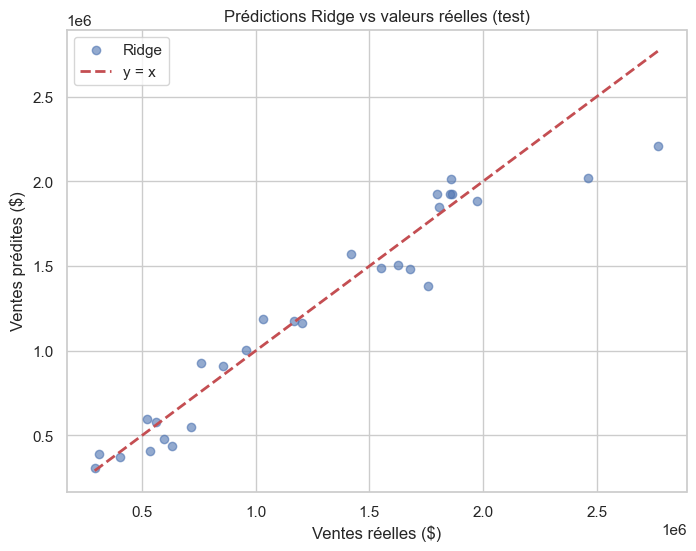

In [24]:
# On visualise Ridge (modèle régularisé) pour illustrer la qualité 
# de ses prédictions. Note : l'écart train/test de Ridge (0.0472) 
# est très légèrement supérieur à celui de la baseline (0.0463).
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_test_pred_ridge, alpha=0.6, label='Ridge')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='y = x')
plt.xlabel("Ventes réelles ($)")
plt.ylabel("Ventes prédites ($)")
plt.title("Prédictions Ridge vs valeurs réelles (test)")
plt.legend()
plt.grid(True)
plt.show()

Les points sont globalement alignés le long de la diagonale, ce qui indique de bonnes prédictions. Les écarts sont surtout visibles aux extrémités (semaines exceptionnelles).

## 6. Discussion, limites et perspectives

### Points forts du projet
- Pipeline Scikit-Learn **entièrement cross-validé** (aucune fuite de données).
- Clipping, imputation et standardisation ajustés **sur le train uniquement**.
- Comparaison systématique train/test pour détecter l'overfitting.
-  Interprétation des coefficients exploitant la standardisation du pipeline 
  pour comparer équitablement l'importance des features.
- Utilisation de `GridSearchCV` pour la sélection d'hyperparamètres.

### Limites identifiées
1. **Taille du dataset** (136 lignes après suppression des cibles manquantes) : les conclusions sont fragiles statistiquement. Une collecte sur plusieurs années et davantage de magasins serait nécessaire pour une robustesse industrielle.
2. **Split aléatoire plutôt que temporel** : justifié par le cadrage descriptif du projet, mais un test de robustesse avec split temporel serait un plus.
3. **Imputation par moyenne** : rapide mais peut introduire un léger biais. Une imputation par modèle (KNN ou régression) serait plus rigoureuse sur des jeux de données plus larges.
4. **Modèles linéaires uniquement** : des modèles non-linéaires (Random Forest, Gradient Boosting) pourraient capturer des interactions plus fines, au prix de l'interprétabilité.
5. **Corrélations faibles entre features et cible** : cela limite intrinsèquement la performance maximale atteignable.

### Perspectives
- **Enrichir les données** : météo locale détaillée, événements locaux, concurrence, promotions marketing.
- **Tester des modèles non-linéaires** : forêts aléatoires, gradient boosting, en comparant rigoureusement avec la baseline linéaire.
- **Industrialisation** : conteneurisation (Docker), suivi des modèles (MLflow), exposition via API (Flask / FastAPI).
- **Test de robustesse** : reproduire l'analyse avec un split temporel pour comparer les performances.

### Recommandations métier
- Le modèle met en évidence des différences importantes de niveau de ventes entre magasins ainsi que des associations entre les variables économiques et les ventes. Ces résultats peuvent servir à orienter des analyses complémentaires, mais ne suffisent pas à eux seuls à déterminer des leviers marketing causaux.

## Conclusion

Ce projet a permis de construire un pipeline de prédiction rigoureux pour estimer les ventes hebdomadaires de Walmart. L'analyse révèle que les trois modèles testés (régression linéaire, Ridge, Lasso) atteignent des performances comparables sur ce dataset — la régularisation n'améliore pas notablement les scores, mais elle agit comme une garantie de robustesse.
L'identification des magasins comme facteur principal et des indicateurs macro-économiques comme facteurs secondaires fournit des **leviers concrets pour la décision marketing**. Ce travail peut servir de base à une phase d'industrialisation, à condition d'enrichir le dataset et de valider les résultats sur un split temporel.